# Schrodinger Cat State

This notebook contains the evolution of Schrodinger Cat State in phase space in the presence of dephasing and anti-dephasing terms.
$$
W_\text{cat} = \mathcal{N} \Bigg[\exp{[-2\{(x-\alpha)^2 + p^2\}]} + \exp{[-2\{(x+\alpha)^2 + p^2\}]} + 2\exp{\{-2(x^2 + p^2)\}\cos(4\alpha p -\phi)}\Bigg]
$$

In [1]:
using FFTW, Interpolations, LinearAlgebra, Plots
gr() 

# ------------------ Parameters ------------------
function decoherence_PDE(use_hbar, γ, Γ, Λ)
    m = 1.0
    A = 1.0
    B = 0.1
    ω = 1.0
    ħ = 0.5
    #use_hbar = true

    x0 = 2.19
    p0 = 0.0
    σx = 0.5
    σp = ħ / (2σx)

    Nx, Np = 256, 256
    xmax, pmax = 6.0, 6.0
    x = range(-xmax, xmax; length=Nx)
    p = range(-pmax, pmax; length=Np)
    dx, dp = step(x), step(p)
    X = repeat(x, 1, Np)
    P = repeat(p', Nx, 1)

    dt = 0.002
    Tfinal = 5.0
    nsteps = Int(round(Tfinal/dt))
    output_every = 50

    # Diffusion control
    use_gamma = true   # diffusion strength

    # ------------------ Initial Wigner ------------------
    α, φ = 2.0, 0.0                # coherent state amplitude             # phase (0 = even cat, π = odd cat)

    W = zeros(Float64, Nx, Np) #Set an empty grid for Wigner function 

    # Normalization factor
    Ncat = 1 / sqrt(2 * (1 + cos(φ) * exp(-2α^2)))

    for ix in 1:Nx, ip in 1:Np
        X1 = x[ix]
        P1 = p[ip]

        # Two coherent states
        W1 = exp(-2 * ((X1 - α)^2 + P1^2))
        W2 = exp(-2 * ((X1 + α)^2 + P1^2))

        # Interference term
        Wint = 2 * exp(-2 * (X1^2 + P1^2)) * cos(4α * P1 - φ)

        W[ix, ip] = (2 / π) * Ncat^2 * (W1 + W2 + Wint)
    end 

    W ./= sum(W) * dx * dp  #Normalize the Wigner function

    # ------------------ Potential ------------------
    V(x,t) = -A*x^2 + B*x^4 + Λ*x*cos(ω*t)
    V′(x,t) = -2A*x + 4B*x^3 + Λ*cos(ω*t)
    V″(x,t) = -2A + 12B*x^2

    # ------------------ Helpers ------------------
    function interpolate_bilinear(W::Matrix, xgrid::AbstractVector, pgrid::AbstractVector)
        interpolate((xgrid, pgrid), W, Gridded(Linear()))
    end

    function classical_step(W, t, τ)
        itp = interpolate_bilinear(W, x, p)
        xback = @. X - (P/m)*τ
        pback = @. P + V′(X, t)*τ
        out = similar(W)
        for i in eachindex(x), j in eachindex(p)
            xb, pb = xback[i,j], pback[i,j]
            if xb < first(x) || xb > last(x) || pb < first(p) || pb > last(p)
                out[i,j] = 0.0
            else
                out[i,j] = itp(xb, pb)
            end
        end
        return out
    end

    # Quantum step via FFT in p-space
    kp = 2π .* fftfreq(Np, 1/dp)
    ik3 = (im .* kp).^3

    function quantum_step(W, τ)
        Ŵ = fft(W, 2)
        if use_hbar
            mult = @. exp(- (ħ^2) * B * x * ik3' * τ)
        else
            mult = ones(size(Ŵ))
        end
        Ŵ .*= mult
        return real(ifft(Ŵ, 2))
    end

    # Smooth absorbing mask
    function make_mask(coord, coord_max; start_frac=0.85, width_frac=0.08)
        start = start_frac * coord_max
        width = width_frac * coord_max
        mask = ones(length(coord))
        for i in eachindex(coord)
            val = abs(coord[i])
            if val > start
                mask[i] = exp(-((val - start)/width)^2)
            end
        end
        return mask
    end

    maskx = make_mask(x, xmax)
    maskp = make_mask(p, pmax)
    mask2d = maskx * maskp'

    # Diagnostics
    function diagnostics(W, t)
        norm = sum(W)*dx*dp
        W_neg = minimum(W)
        total_neg_area = sum(abs.(W[W .< 0])) * dx * dp
        total_log_neg_area = log(sum(abs.(W))*dx*dp)
        return (t=t, norm=norm, W_neg = W_neg, total_neg_area = total_neg_area, total_log_neg_area = total_log_neg_area)
    end

    # --- Parameters you can tune ---
                # your gamma (choose appropriate)
    exponent_threshold = 1.0 # target max magnitude per substep (≈|exponent| <= 1)
    exponent_clamp = 60.0    # hard clamp to avoid overflow in exp

    # --- Dissipator step (in-place) ---
    function dissipator_step!(W::AbstractMatrix, t::Float64, τ::Float64;
                            Γ::Float64=Γ, dx::Float64=dx, dp::Float64=dp,
                            exponent_threshold::Float64=exponent_threshold,
                            exponent_clamp::Float64=exponent_clamp)

        # compute H and H^2 on grid (same time t used for V as elsewhere)
        H = @. (P.^2)/(2m) + V(X, t)
        H2 = @. H^2

        # compute global mean <H^2> with current W
        H2mean = sum(H2 .* W) * dx * dp

        # compute maximum magnitude of exponent for whole grid for full τ
        max_exponent = maximum(abs.(-4.0*Γ*(H2 .- H2mean)*τ))

        # choose number of substeps to keep per-substep exponent <= threshold
        nsub = max(1, ceil(Int, max_exponent / exponent_threshold))

        τsub = τ / nsub
        prev_norm = sum(W) * dx * dp  # store norm to restore later

        for s in 1:nsub
            # recompute exponent for substep using same H2mean (frozen for substep series)
            expo = @. -4.0*Γ*(H2 .- H2mean)*τsub

            # clamp to avoid overflow; choice of clamp depends on problem
            @. expo = clamp(expo, -exponent_clamp, exponent_clamp)

            # apply multiplicative factor
            @. W = W * exp(expo)
        end

        # renormalize to preserve mass (the continuous equation conserves it)
        W ./= (sum(W)*dx*dp) / prev_norm

        return nothing
    end

    # ------------------ ADI Diffusion Step ------------------
    """
    ADI semi-implicit step for diffusion-like operator:
        W_t = γ [ (p/m)^2 ∂_x^2 W + (V'(x,t))^2 ∂_p^2 W ]
    Cross terms are neglected for stability & speed.
    """
    function diffusion_step_ADI!(W, t, γ, dt)
        Nx, Np = size(W)
        if γ == 0.0
            return W
        end

        # Compute coefficients
        Vp = @. V′(x, t)
        P2 = (p.^2) / m^2
        αx = @. 0.5 * dt * γ * P2 / dx^2
        αp = @. 0.5 * dt * γ * (Vp^2) / dp^2

        # --- X-direction implicit step ---
        Wtmp = similar(W)
        for j in 1:Np
            # Build tridiagonal system along x for fixed p_j
            a = -αx
            b = 1 .+ 2αx
            c = -αx
            rhs = W[:, j]
            Wtmp[:, j] = Tridiagonal(a[2:end], b, c[1:end-1]) \ rhs
        end

        # --- P-direction implicit step ---
        Wnew = similar(W)
        for i in 1:Nx
            a = -αp
            b = 1 .+ 2αp
            c = -αp
            rhs = Wtmp[i, :]
            Wnew[i, :] = (Tridiagonal(a[2:end], b, c[1:end-1]) \ rhs)'
        end

        return Wnew
    end

    # ------------------ Time Evolution ------------------
    t = 0.0
    Wframes = [copy(W)]
    diagnostics_list = [diagnostics(W,t)]

    for step in 1:nsteps
        # Classical → Quantum → Classical (Strang)
        W = classical_step(W, t, dt/2)

        # dissipator half-step
        dissipator_step!(W, t, dt/2; Γ=Γ, dx=dx, dp=dp)

        if use_gamma
            W = diffusion_step_ADI!(W, t, γ, dt/2)
        end

        W .= quantum_step(W, dt)

        if use_gamma
            W = diffusion_step_ADI!(W, t+dt/2, γ, dt/2)
        end

        # dissipator half-step (use t+dt since we've advanced in time)
        dissipator_step!(W, t+dt, dt/2; Γ=Γ, dx=dx, dp=dp)

        W = classical_step(W, t+dt, dt/2)

        # Absorbing mask
        W .*= mask2d

        # Renormalization
        if step % 50 == 0
            W ./= sum(W) * dx * dp
        end

        t += dt
        if step % output_every == 0 || step == nsteps
            push!(diagnostics_list, diagnostics(W,t))
            push!(Wframes, copy(W))
        end
    end

    # ------------------ Diagnostics Summary ------------------
    ts = [d.t for d in diagnostics_list]
    norms = [d.norm for d in diagnostics_list]
    W_min = [d.W_neg for d in diagnostics_list]
    total_neg_area = [d.total_neg_area for d in diagnostics_list]
    total_log_neg_area = [d.total_log_neg_area for d in diagnostics_list]

    return ts, norms, W_min, total_neg_area, total_log_neg_area, Wframes
end

decoherence_PDE (generic function with 1 method)

In [2]:
γ, Γ, Λ = 0.05,0.1,0.2
sample_run = decoherence_PDE(true, γ, Γ, Λ)

([0.0, 0.10000000000000007, 0.20000000000000015, 0.3000000000000002, 0.4000000000000003, 0.5000000000000003, 0.6000000000000004, 0.7000000000000005, 0.8000000000000006, 0.9000000000000007  …  4.0999999999997705, 4.1999999999997595, 4.2999999999997485, 4.3999999999997375, 4.499999999999726, 4.599999999999715, 4.699999999999704, 4.799999999999693, 4.899999999999682, 4.999999999999671], [1.0, 0.9999999999999997, 1.0, 1.0, 0.9999999999999997, 1.0, 1.0000000000000002, 1.0, 0.9999999999999998, 1.0000000000000002  …  1.0000000000000002, 1.0000000000000002, 1.0000000000000002, 0.9999999999999997, 1.0, 1.0, 1.0, 1.0, 0.9999999999999997, 0.9999999999999998], [-0.4704909550744964, -0.5355900548821858, -0.6007667466174778, -0.6401638149479375, -0.6343330401914411, -0.578743180665279, -0.5191514934248521, -0.47157422498238455, -0.4306240547308957, -0.3855459290433125  …  0.0, 0.0, 0.0, 0.0, 0.0, -1.2621051106371463e-5, -0.00014360968863063355, -0.0002986639801262832, -0.0004604571983706785, -0.0006

# Range of $\Lambda$

In [3]:
using Base.Threads
function Lambda_range(γ, Γ)
   runs = 5
   Λ_range = range(0.1, 1.0, length=runs)
   sample_run = decoherence_PDE(true, γ, Γ, Λ_range[1]);
   t_range = sample_run[1]

   Log_neg_list = Array{Float64}(undef, runs, length(t_range))
   Log_neg_list[1,:] = sample_run[5]

   @threads for j in 2:runs
      Log_neg_list[j,:] = decoherence_PDE(true,γ, Γ, Λ_range[j])[5] 
   end
   return γ, Γ, runs, Λ_range, t_range, Log_neg_list
end

Lambda_range (generic function with 1 method)

In [4]:
PL = range(colorant"lightblue1",stop=colorant"midnightblue",length=5)

In [5]:
lambda_set_01 = Lambda_range(0.01, 0.01);
lambda_set_11 = Lambda_range(0.01, 0.1);
lambda_set_21 = Lambda_range(0.1, 0.01);
lambda_set_22 = Lambda_range(0.1, 0.1);

In [6]:
using LaTeXStrings

function plot_lambda_range(lambda_range_output, x_label, y_label, x_ticks, y_ticks)
    γ, Γ, runs, Λ_range, t_range, Log_neg_list = lambda_range_output

    PL = range(colorant"lightblue1",stop=colorant"midnightblue",length=10)

    default(titlefontsize=18, guidefontsize=20, tickfontsize=16, legendfontsize=16, labelfontsize = 20)
    plt = plot(fontfamily = "Computer Modern")

    for j in 1:runs
        Λ_val = Λ_range[j]
        plot!(plt, t_range, Log_neg_list[j,:], label = L"Λ = %$Λ_val", frame = :box, grid = false, lc = PL[j], legend = false,
        xticks = x_ticks, yticks = y_ticks)
    end

    if y_label ==  true
        plot!(plt, ylabel = L"$\mathcal{W}$")
    end

    if x_label ==  true
        plot!(plt, xlabel = L"$t$")
    end

    return plt
end

plot_lambda_range (generic function with 1 method)

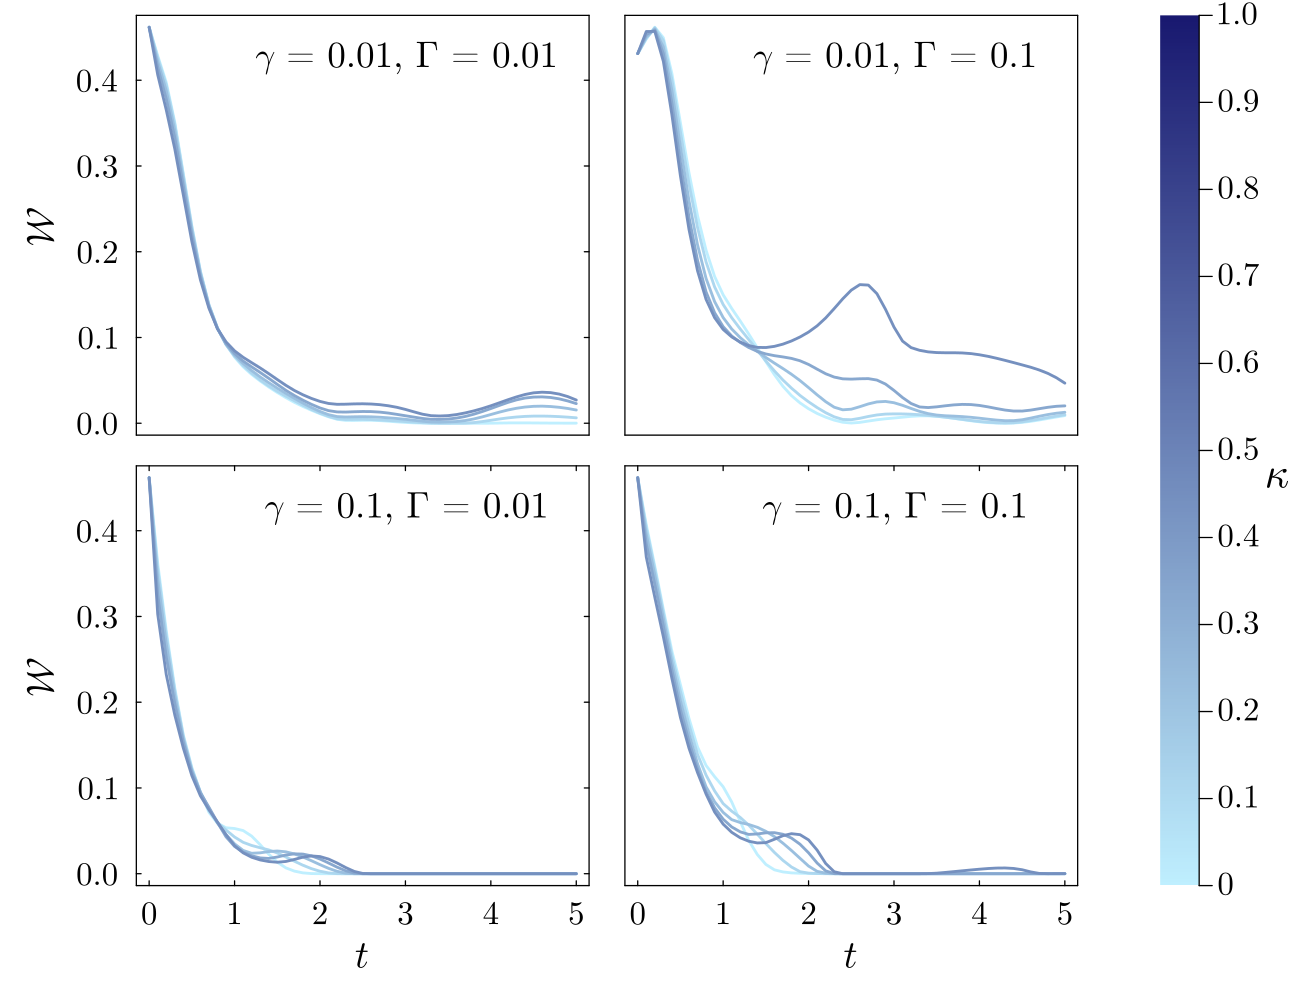

GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT
GKS: Rectangle definition is invalid in routine SET_VIEWPORT


"/Users/ankit.wenjushrestha/Research Codes/Wig_log_neg_Lambda_CAT.pdf"

In [ ]:
using Measures
Plots.scalefontsizes(1.2)
ann_f_size = 18
plt_01 = plot_lambda_range(lambda_set_01, false, true, false, true)
plot!(plt_01, annotate = (3.0,0.42,text(L"$\gamma$ = 0.01, Γ = 0.01", font(ann_f_size,"Computer Modern"))), right_margin = 2mm)

plt_11 = plot_lambda_range(lambda_set_11, false, false, false, false)
plot!(plt_11, annotate = (3.0,0.45,text(L"$\gamma$ = 0.01, Γ = 0.1", font(ann_f_size,"Computer Modern"))))

plt_21 = plot_lambda_range(lambda_set_21, true, true, true, true)
plot!(plt_21, annotate = (3.0,0.42,text(L"$\gamma$ = 0.1, Γ = 0.01", font(ann_f_size,"Computer Modern"))))

plt_22 = plot_lambda_range(lambda_set_22, true, false, true, false)
plot!(plt_22, annotate = (3.0,0.42,text(L"$\gamma$ = 0.1, Γ = 0.1", font(ann_f_size,"Computer Modern"))))

l = @layout [a{0.95w} b]
cmap = cgrad(PL)
pA = plot(plt_01, plt_11, 
        plt_21, plt_22, layout = (2,2), size=(1300, 1000), lw = 2.2)
p2 = heatmap(rand(2,2), clims=(0,1), framestyle=:none, c=cmap, cbar=true, lims=(-1,0),cbar_title=L"  $\kappa$", colorbar_titlefontsize = 22, legend = false)
pB = plot(pA, p2, layout=l, fontfamily = "Computer Modern", thickness_scaling = 1.3, fontcolor = :black, colorbar_titlefontrotation = 270)

display(pB)
#savefig(pB, "Wig_log_neg_Lambda_CAT.pdf")

# Animation

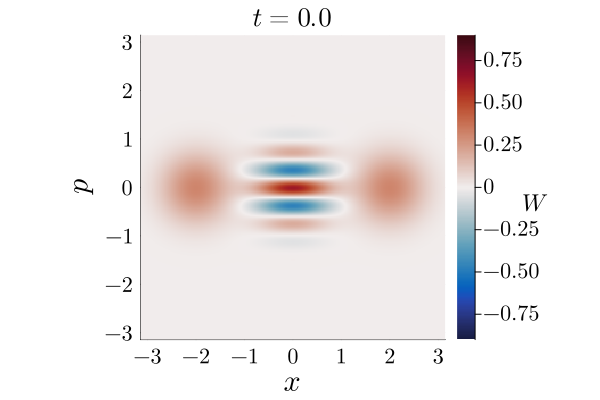

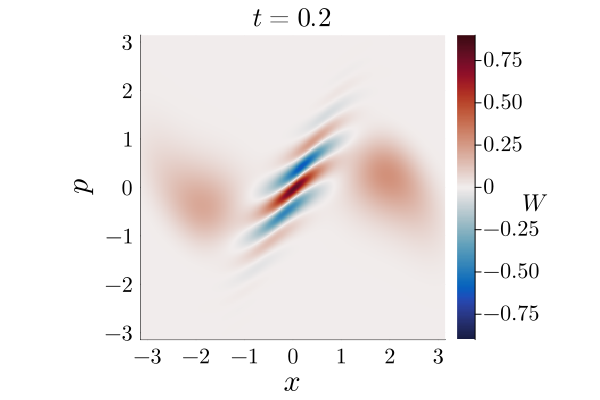

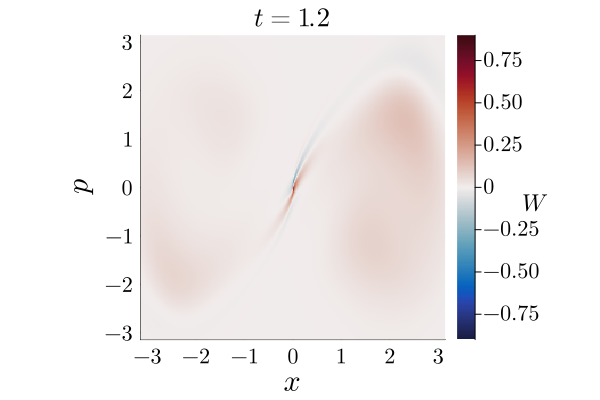

In [21]:
using Plots, LaTeXStrings
ts = sample_run[1]
Wframes = sample_run[6]

Nx, Np = 512, 512 #256, 256
xmax, pmax = 6.0, 6.0
x = range(-xmax, xmax; length=Nx)
p = range(-pmax, pmax; length=Np)

# =============================================================
# Plot individual W(q,p,t) snapshots
# =============================================================

times_to_plot = [0.0, 0.2,1.2]

# Find nearest solution indices for those times
indices = [findmin(abs.(ts .- t))[2] for t in times_to_plot]
heatmap_list = []
surface_list = []

default(titlefontsize=18, guidefontsize=16, tickfontsize=14, labelfontsize = 20, colorbar_titlefontsize = 16, fontfamily = "Computer Modern")
for (i, idx) in enumerate(indices)
    Wmat = Wframes[idx]
    tval = round(ts[idx]; digits=2)

    p1 = heatmap(x, p, Wmat',
                xlabel=L"$x$", ylabel=L"$p$", zlabel = L"$W$",
                title=L"$t = %$tval$",
             xlim=(-π, π), ylim=(-π, π),aspect_ratio=1, c= :balance, clims = (-0.9,0.9), camera = (55, 10), zlims = (-0.8,0.8),
             cbar_title = L"       $W$", colorbar_titlefontrotation = 270)

    # p2 =surface(x, p, Wmat',
    #         xlabel=L"$x$", ylabel=L"$p$", zlabel = L"$W$",
    #         title=L"$t = %$tval$",
    #         xlim=(-π, π), ylim=(-π, π),aspect_ratio=1, c= :balance, clims = (-0.8,0.8), camera = (55, 10), zlims = (-0.8,0.8),
    #         cbar_title = L"          $W$", colorbar_titlefontrotation = 270)


    savefig(p1, "wigner_CAT_t=$(tval).pdf")
    push!(heatmap_list, p1)
    #push!(surface_list, p2)
    display(p1)
end